In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tabulate import tabulate

In [2]:
data =pd.read_excel("enaho2019limpia.xlsx")
print(data.head(4))

    AÑO  MES  NCONGLOME  CONGLOME  VIVIENDA  HOGAR  CODPERSO  UBIGEO  DOMINIO  \
0  2019    5      18584      7481        42     11         1  150139        8   
1  2019    5      18584      7481        54     11         3  150139        8   
2  2019    4      18626      7482        29     11         2  150102        8   
3  2019    4      18626      7482        29     11         3  150102        8   

   ESTRATO  ...  T560_075  T560_076  T560_077  T560_078  T560_08  T560_09  \
0        1  ...         2         2         2         2        2        2   
1        1  ...         2         2         2         2        2        2   
2        1  ...         2         2         2         2        2        2   
3        1  ...         2         2         2         2        2        2   

   T560_10  OCUPINF  EMPLPSEC      FAC500A  
0        2        2             978.145081  
1        2        1         2  1245.660278  
2        2        1         2   931.481018  
3        2        2         

In [3]:
Q1 = data['P524A1'].quantile(0.25)
Q3 = data['P524A1'].quantile(0.75)
IQR = Q3 - Q1
filtered_data = data[(data['P524A1'] >= Q1 - 1.5 * IQR) & (data['P524A1'] <= Q3 + 1.5 * IQR)]
filtered_data['P524A1'].describe()

,P524A1
count,3133.000000
mean,1317.991701
std,1004.960871
min,10.000000
25%,500.000000
50%,1051.000000
75%,1800.000000
max,4600.000000


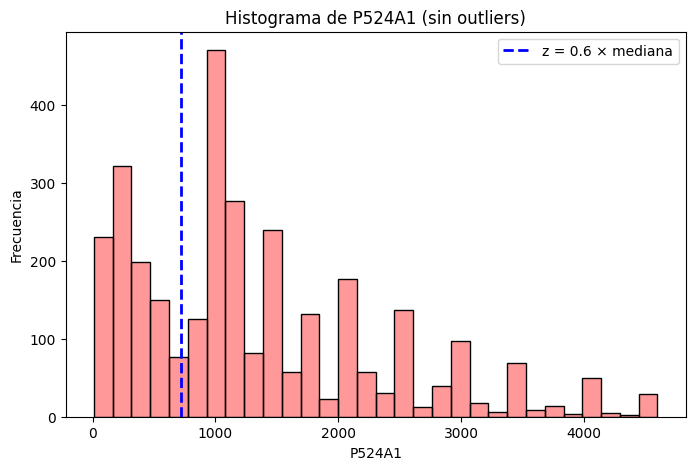

In [4]:
z = 0.6 * data['P524A1'].median()
Q1 = data['P524A1'].quantile(0.25)
Q3 = data['P524A1'].quantile(0.75)
IQR = Q3 - Q1
filtered_data = data[(data['P524A1'] >= Q1 - 1.5 * IQR) & (data['P524A1'] <= Q3 + 1.5 * IQR)]
plt.figure(figsize=(8,5))
sns.histplot(filtered_data['P524A1'], bins=30, color='red', alpha=0.4, edgecolor='black')
plt.axvline(x=z, color='blue', linestyle='--', linewidth=2, label='z = 0.6 × mediana')
plt.title('Histograma de P524A1 (sin outliers)')
plt.xlabel('P524A1')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

**UMBRAL DE POBREZA**

In [5]:
z = 0.6 * data['P524A1'].median()
print(z)

720.0


In [6]:
n = data.shape[0]
data['poor'] = np.where(data['P524A1'] < z, 1, 0)
print(data['poor'].value_counts())

poor
0    2476
1     959
Name: count, dtype: int64


**TAMAÑO POBLACIONAL**

In [7]:
datos_censales=pd.read_excel("DATOS CENSALES.xlsx")
print(datos_censales)

    UBIGEO      NOMBRE DEL DISTRITO   POBLACION CENSADA
0   150101                      Lima             268352
1   150102                     Ancon              62928
2   150103                       Ate             599196
3   150104                  Barranco              34378
4   150105                     Breña              85309
5   150106                Carabayllo             333045
6   150107                Chaclacayo              42912
7   150108               Chorrillos              314241
8   150109               Cieneguilla              34684
9   150110                     Comas             520450
10  150111               El Agustino             198862
11  150112            Independencia              211360
12  150113               Jesus Maria              75359
13  150114                 La Molina             140679
14  150115               La Victoria             173630
15  150116                     Lince              54711
16  150117                Los Olivos            

**ESTIAMACIÓN DIRECTA**

In [8]:
muestra = pd.read_excel("enaho2019limpia.xlsx")
censo = pd.read_excel("DATOS CENSALES.xlsx")
var_y = "P524A1"
var_dom = "UBIGEO"
var_w = "FAC500A"
muestra = muestra.copy()
muestra = muestra[muestra[var_y].notnull()]
muestra.loc[muestra[var_y].isin([9999, 99999, 999999]), var_y] = np.nan
muestra = muestra[muestra[var_y].between(100, 20000)]


def est_directos(x):
    if x[var_y].notnull().sum() == 0:
        return pd.Series({
            "Y_direct": np.nan,
            "SD_direct": np.nan,
            "CV_direct": np.nan,
            "n_muestra": 0
        })
    w = x[var_w]
    y = x[var_y]
    y_mean = np.average(y, weights=w)
    var_dir = np.sum((w**2) * (y - y_mean)**2) / (np.sum(w)**2)
    sd_dir = np.sqrt(var_dir)
    cv_dir = (sd_dir / y_mean) * 100
    return pd.Series({
        "Y_direct": y_mean,
        "SD_direct": sd_dir,
        "CV_direct": cv_dir,
        "n_muestra": x[var_y].notnull().sum()
    })
result = muestra.groupby(var_dom).apply(est_directos).reset_index()
result = pd.merge(censo[[var_dom, "POBLACION CENSADA"]], result, on=var_dom, how="left")
print(tabulate(result.head(42), headers="keys", tablefmt="fancy_grid", floatfmt=".2f"))

╒════╤═══════════╤═════════════════════╤════════════╤═════════════╤═════════════╤═════════════╕
│    │    UBIGEO │   POBLACION CENSADA │   Y_direct │   SD_direct │   CV_direct │   n_muestra │
╞════╪═══════════╪═════════════════════╪════════════╪═════════════╪═════════════╪═════════════╡
│  0 │ 150101.00 │           268352.00 │    1556.63 │      111.33 │        7.15 │      235.00 │
├────┼───────────┼─────────────────────┼────────────┼─────────────┼─────────────┼─────────────┤
│  1 │ 150102.00 │            62928.00 │     910.33 │      113.33 │       12.45 │       14.00 │
├────┼───────────┼─────────────────────┼────────────┼─────────────┼─────────────┼─────────────┤
│  2 │ 150103.00 │           599196.00 │    1161.27 │       95.23 │        8.20 │      156.00 │
├────┼───────────┼─────────────────────┼────────────┼─────────────┼─────────────┼─────────────┤
│  3 │ 150104.00 │            34378.00 │    1358.42 │      296.89 │       21.86 │       19.00 │
├────┼───────────┼─────────────────────┼

/tmp/ipython-input-504388772.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = muestra.groupby(var_dom).apply(est_directos).reset_index()


**NUMERO DE DISTRITOS EN LIMA**

In [9]:
muestra = pd.read_excel("enaho2019limpia.xlsx")
censo = pd.read_excel("DATOS CENSALES.xlsx")
muestra.columns = muestra.columns.str.strip()
censo.columns = censo.columns.str.strip()
col_distrito = [c for c in censo.columns if "NOMBRE" in c.upper() and "DISTRITO" in c.upper()][0]
conteo = muestra['UBIGEO'].value_counts().reset_index()
conteo.columns = ['UBIGEO', 'N_Muestra']
tabla = censo[['UBIGEO', col_distrito]].merge(conteo, on='UBIGEO', how='left')
tabla['N_Muestra'] = tabla['N_Muestra'].fillna(0).astype(int)

print(tabulate(tabla.head(60), headers='keys', tablefmt='fancy_grid'))

╒════╤══════════╤═════════════════════════╤═════════════╕
│    │   UBIGEO │ NOMBRE DEL DISTRITO     │   N_Muestra │
╞════╪══════════╪═════════════════════════╪═════════════╡
│  0 │   150101 │ Lima                    │         242 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  1 │   150102 │ Ancon                   │          15 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  2 │   150103 │ Ate                     │         167 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  3 │   150104 │ Barranco                │          21 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  4 │   150105 │ Breña                   │          51 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  5 │   150106 │ Carabayllo              │          97 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  6 │   150107 │ Chaclacayo              │          13 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  7 │   15010

**MATRIZ DE LAS COVARIABLES**

In [10]:
aux = pd.read_excel("variable_auxiliares.xlsx")
print(aux.columns)

Index(['UBIGEO', 'NOMBRE_DISTRITO ', 'semana_trabajo', 'conexion_internet '], dtype='object')


In [11]:
auxiliares = pd.read_excel("variable_auxiliares.xlsx")
auxiliares = auxiliares.sort_values("UBIGEO").reset_index(drop=True)
ubigeo = auxiliares["UBIGEO"]
X_vars = auxiliares.drop(columns=["UBIGEO"]).to_numpy()
const = np.ones((X_vars.shape[0], 1))
X = np.hstack([const, X_vars])
columnas = ["const"] + list(auxiliares.columns[1:])
X_df = pd.DataFrame(X, columns=columnas)
X_df.insert(0, "UBIGEO", ubigeo)
print(tabulate(X_df.head(52), headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

╒════╤══════════╤═════════╤═════════════════════════╤══════════════════╤══════════════════════╕
│    │   UBIGEO │   const │ NOMBRE_DISTRITO         │   semana_trabajo │   conexion_internet  │
╞════╪══════════╪═════════╪═════════════════════════╪══════════════════╪══════════════════════╡
│  0 │   150101 │    1.00 │ Lima                    │             0.48 │                 0.57 │
├────┼──────────┼─────────┼─────────────────────────┼──────────────────┼──────────────────────┤
│  1 │   150102 │    1.00 │ Ancon                   │             0.44 │                 0.29 │
├────┼──────────┼─────────┼─────────────────────────┼──────────────────┼──────────────────────┤
│  2 │   150103 │    1.00 │ Ate                     │             0.47 │                 0.39 │
├────┼──────────┼─────────┼─────────────────────────┼──────────────────┼──────────────────────┤
│  3 │   150104 │    1.00 │ Barranco                │             0.54 │                 0.75 │
├────┼──────────┼─────────┼─────────────

In [12]:
X_numeric = X_df.select_dtypes(include=[np.number]).to_numpy()
ubigeo = X_df['UBIGEO'].to_numpy()

In [13]:
import scipy.stats

X = np.column_stack([
    np.ones(len(aux)),
    aux['semana_trabajo'].to_numpy(),
    aux['conexion_internet '].to_numpy()
])
Y = result['Y_direct'].to_numpy()
vardir = result['SD_direct'].to_numpy()**2
mask = (~np.isnan(Y)) & (vardir > 0)
Y_valid = Y[mask]
X_valid = X[mask, :]
vardir_valid = vardir[mask]
W = np.diag(1 / vardir_valid)
XtW = X_valid.T @ W
beta_hat = np.linalg.inv(XtW @ X_valid) @ XtW @ Y_valid
cov_beta = np.linalg.inv(XtW @ X_valid)
se_beta = np.sqrt(np.diag(cov_beta))
t_values = beta_hat / se_beta
p_values = 2 * (1 - scipy.stats.norm.cdf(np.abs(t_values)))
coef_table = pd.DataFrame({
    'beta': beta_hat,
    'SE': se_beta,
    't_value': t_values,
    'p_value': p_values
}, index=['Intercepto', 'semana_trabajo', 'conexion_internet'])

print("Coeficientes del modelo Fay–Herriot:")
print(tabulate(coef_table, headers='keys', tablefmt='fancy_grid', floatfmt=".4f"))

Coeficientes del modelo Fay–Herriot:
╒═══════════════════╤═══════════╤══════════╤═══════════╤═══════════╕
│                   │      beta │       SE │   t_value │   p_value │
╞═══════════════════╪═══════════╪══════════╪═══════════╪═══════════╡
│ Intercepto        │ -749.3790 │ 288.5676 │   -2.5969 │    0.0094 │
├───────────────────┼───────────┼──────────┼───────────┼───────────┤
│ semana_trabajo    │ 1167.9972 │ 673.0317 │    1.7354 │    0.0827 │
├───────────────────┼───────────┼──────────┼───────────┼───────────┤
│ conexion_internet │ 3300.1862 │ 143.4657 │   23.0033 │    0.0000 │
╘═══════════════════╧═══════════╧══════════╧═══════════╧═══════════╛


In [14]:
import numpy as np
from scipy.optimize import minimize


Y_valid = Y[mask]
X_valid = X_numeric[mask, :]
D_valid = vardir[mask]

def reml_loglik(sigma_u2):
    sigma_u2 = sigma_u2[0] if isinstance(sigma_u2, np.ndarray) else sigma_u2
    V = D_valid + sigma_u2
    Vi = 1 / V
    XtViX = X_valid.T @ (Vi[:, None] * X_valid)
    beta_hat = np.linalg.solve(XtViX, X_valid.T @ (Vi * Y_valid))
    resid = Y_valid - X_valid @ beta_hat
    ll = 0.5 * (np.sum(np.log(V)) + np.log(np.linalg.det(XtViX)) + np.sum(resid**2 * Vi))
    return ll


res = minimize(reml_loglik, x0=[0.1], bounds=[(0, None)])
sigma_u2_hat = res.x[0]

# --- Resultado ---
print(f"Varianza del efecto aleatorio (σ²_u) estimada por REML: {sigma_u2_hat:.6f}")

Varianza del efecto aleatorio (σ²_u) estimada por REML: 847167.434012


In [15]:
import numpy as np
import pandas as pd
from tabulate import tabulate


col_distrito = [c for c in censo.columns if "NOMBRE" in c.upper() and "DISTRITO" in c.upper()][0]


X_numeric = np.column_stack([
    np.ones(len(aux)),
    aux['semana_trabajo'].to_numpy(),
    aux['conexion_internet '].to_numpy()
])

Y = result['Y_direct'].to_numpy()
D_i = result['SD_direct'].to_numpy()**2
A = sigma_u2_hat
mask = (~np.isnan(Y)) & (D_i > 0)
Y_valid = Y[mask]
X_valid = X_numeric[mask, :]
D_valid = D_i[mask]

W = np.diag(1 / D_valid)
XtW = X_valid.T @ W
beta_hat = np.linalg.inv(XtW @ X_valid) @ XtW @ Y_valid
beta_hat = np.ravel(beta_hat)

print("Forma de X_numeric:", X_numeric.shape)
print("Forma de beta_hat:", beta_hat.shape)
print("Coeficientes beta_hat:", beta_hat)

Y_model = X_numeric @ beta_hat
gamma = A / (A + D_i)
gamma[np.isnan(D_i)] = 0

u_hat = (1 - gamma) * (Y - Y_model)
u_hat[np.isnan(Y)] = Y_model[np.isnan(Y)]
gamma_df = pd.DataFrame({
    'UBIGEO': result['UBIGEO'],
    'Nombre Distrito': censo[col_distrito].values,
    'Gamma': gamma,
    'u_hat': u_hat
})
print(tabulate(gamma_df.head(52), headers='keys', tablefmt='fancy_grid', floatfmt=".4f"))

Forma de X_numeric: (43, 3)
Forma de beta_hat: (3,)
Coeficientes beta_hat: [-749.3790389  1167.99715967 3300.18619224]
╒════╤══════════╤═════════════════════════╤═════════╤═══════════╕
│    │   UBIGEO │ Nombre Distrito         │   Gamma │     u_hat │
╞════╪══════════╪═════════════════════════╪═════════╪═══════════╡
│  0 │   150101 │ Lima                    │  0.9856 │   -2.0246 │
├────┼──────────┼─────────────────────────┼─────────┼───────────┤
│  1 │   150102 │ Ancon                   │  0.9851 │    2.7596 │
├────┼──────────┼─────────────────────────┼─────────┼───────────┤
│  2 │   150103 │ Ate                     │  0.9894 │    0.8578 │
├────┼──────────┼─────────────────────────┼─────────┼───────────┤
│  3 │   150104 │ Barranco                │  0.9058 │  -93.1179 │
├────┼──────────┼─────────────────────────┼─────────┼───────────┤
│  4 │   150105 │ Breña                   │  0.9742 │  -14.5984 │
├────┼──────────┼─────────────────────────┼─────────┼───────────┤
│  5 │   150106 │ Carab

In [16]:
censo.columns = censo.columns.str.strip()
X_df.columns = X_df.columns.str.strip()
col_distrito = [c for c in censo.columns if "NOMBRE" in c.upper() and "DISTRITO" in c.upper()][0]
X_numeric = X_df.select_dtypes(include=[np.number]).to_numpy(dtype=np.float64)
ubigeo = X_df["UBIGEO"].to_numpy()
Y = result['Y_direct'].to_numpy(dtype=np.float64)
SD = result['SD_direct'].to_numpy(dtype=np.float64)
vardir = SD**2
mask = (~np.isnan(Y)) & (vardir > 0)
Y_valid = Y[mask]
X_valid = X_numeric[mask, :]
vardir_valid = vardir[mask]
W = np.diag(1 / vardir_valid)
XtW = X_valid.T @ W
beta_hat = np.linalg.inv(XtW @ X_valid) @ XtW @ Y_valid
Y_model = X_numeric @ beta_hat
EBLUP = np.copy(Y_model)

for i in range(len(Y)):
    if not np.isnan(Y[i]):
        gamma = sigma_u2_hat / (sigma_u2_hat + vardir[i])
        EBLUP[i] = gamma * Y[i] + (1 - gamma) * Y_model[i]
    else:
        EBLUP[i] = Y_model[i]
Var_EBLUP = np.zeros_like(Y)
for i in range(len(Y)):
    if not np.isnan(Y[i]):
        gamma = sigma_u2_hat / (sigma_u2_hat + vardir[i])
        Var_EBLUP[i] = gamma**2 * vardir[i] + (1 - gamma)**2 * sigma_u2_hat
    else:
        Var_EBLUP[i] = sigma_u2_hat
SE_EBLUP = np.sqrt(Var_EBLUP)
CV_EBLUP = SE_EBLUP / np.where(np.isclose(EBLUP, 0), np.nan, EBLUP) * 100

eblup_df = pd.DataFrame({
    "UBIGEO": ubigeo,
    "EBLUP": EBLUP,
    "SE_EBLUP": SE_EBLUP,
    "CV_EBLUP": CV_EBLUP,
    "Y_direct": Y,
    "SD_direct": SD
})

distritos = censo[['UBIGEO', col_distrito]]
eblup_df = pd.merge(eblup_df, distritos, on="UBIGEO", how='left')
eblup_df = eblup_df[["UBIGEO", col_distrito, "Y_direct", "SD_direct", "EBLUP", "SE_EBLUP", "CV_EBLUP"]]

print(tabulate(eblup_df.head(52), headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))


╒════╤══════════╤═════════════════════════╤════════════╤═════════════╤═════════╤════════════╤════════════╕
│    │   UBIGEO │ NOMBRE DEL DISTRITO     │   Y_direct │   SD_direct │   EBLUP │   SE_EBLUP │   CV_EBLUP │
╞════╪══════════╪═════════════════════════╪════════════╪═════════════╪═════════╪════════════╪════════════╡
│  0 │   150101 │ Lima                    │    1556.63 │      111.33 │ 1547.95 │     110.52 │       7.14 │
├────┼──────────┼─────────────────────────┼────────────┼─────────────┼─────────┼────────────┼────────────┤
│  1 │   150102 │ Ancon                   │     910.33 │      113.33 │  910.98 │     112.49 │      12.35 │
├────┼──────────┼─────────────────────────┼────────────┼─────────────┼─────────┼────────────┼────────────┤
│  2 │   150103 │ Ate                     │    1161.27 │       95.23 │ 1159.08 │      94.73 │       8.17 │
├────┼──────────┼─────────────────────────┼────────────┼─────────────┼─────────┼────────────┼────────────┤
│  3 │   150104 │ Barranco           

In [17]:
D_i = eblup_df['SD_direct']**2
A = sigma_u2_hat
gamma = A / (A + D_i)
eblup_df['gamma'] = gamma
gamma_series = pd.Series(gamma)
summary_gamma = {
    'Min.': gamma_series.min(),
    '1st Qu.': gamma_series.quantile(0.25),
    'Median': gamma_series.median(),
    'Mean': gamma_series.mean(),
    '3rd Qu.': gamma_series.quantile(0.75),
    'Max.': gamma_series.max()
}

print("\nResumen de la variable gamma (ponderación Fay-Herriot):")
for k, v in summary_gamma.items():
    print(f"{k:8}: {v:.4f}")



Resumen de la variable gamma (ponderación Fay-Herriot):
Min.    : 0.3305
1st Qu. : 0.8716
Median  : 0.9751
Mean    : 0.9098
3rd Qu. : 0.9874
Max.    : 0.9990


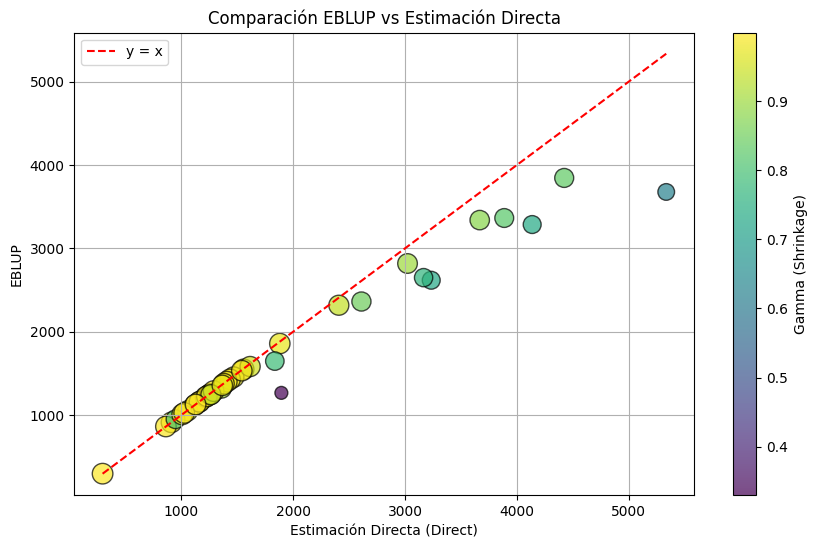

In [18]:
D_i = eblup_df['SD_direct']**2
A = sigma_u2_hat
eblup_df['gamma'] = A / (A + D_i)
plot_df = eblup_df.dropna(subset=['Y_direct', 'EBLUP', 'gamma']).copy()
plot_df['diff'] = plot_df['EBLUP'] - plot_df['Y_direct']

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    plot_df['Y_direct'],
    plot_df['EBLUP'],
    s=plot_df['gamma']*200 + 20,
    c=plot_df['gamma'],
    cmap='viridis',
    alpha=0.7,
    edgecolor='black'
)
plt.plot(
    [plot_df['Y_direct'].min(), plot_df['Y_direct'].max()],
    [plot_df['Y_direct'].min(), plot_df['Y_direct'].max()],
    color='red', linestyle='--', label='y = x'
)

plt.xlabel('Estimación Directa (Direct)')
plt.ylabel('EBLUP')
plt.title('Comparación EBLUP vs Estimación Directa')
plt.grid(True)
plt.legend()
cbar = plt.colorbar(scatter)
cbar.set_label('Gamma (Shrinkage)')
plt.show()

In [19]:
tasa_inflacion = 0.0190


eblup_df["EBLUP_real"] = eblup_df["EBLUP"] / (1 + tasa_inflacion)
eblup_df["EBLUP_real"] = eblup_df["EBLUP_real"].round(2)


resultado = eblup_df[[col_distrito, "EBLUP", "EBLUP_real"]].copy()


resultado = resultado.sort_values(by="EBLUP_real", ascending=False)

print(f"\n✅ Tasa de inflación aplicada: {tasa_inflacion*100:.2f}%\n")
print(tabulate(resultado.head(20), headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))


resultado.to_excel("EBLUP_AJUSTADO.xlsx", index=False)
print("\n📂 Archivo exportado correctamente como 'EBLUP_AJUSTADO.xlsx'")


✅ Tasa de inflación aplicada: 1.90%

╒════╤════════════════════════╤═════════╤══════════════╕
│    │ NOMBRE DEL DISTRITO    │   EBLUP │   EBLUP_real │
╞════╪════════════════════════╪═════════╪══════════════╡
│ 21 │ Miraflores             │ 3845.90 │      3774.19 │
├────┼────────────────────────┼─────────┼──────────────┤
│ 30 │ San Isidro             │ 3677.63 │      3609.06 │
├────┼────────────────────────┼─────────┼──────────────┤
│ 29 │ San Borja              │ 3364.77 │      3302.03 │
├────┼────────────────────────┼─────────┼──────────────┤
│ 39 │ Santiago de Surco      │ 3339.59 │      3277.32 │
├────┼────────────────────────┼─────────┼──────────────┤
│ 12 │ Jesus Maria            │ 3286.26 │      3224.99 │
├────┼────────────────────────┼─────────┼──────────────┤
│ 20 │ Pueblo Libre           │ 2818.43 │      2765.87 │
├────┼────────────────────────┼─────────┼──────────────┤
│ 19 │ Magdalena del Mar      │ 2648.77 │      2599.38 │
├────┼────────────────────────┼─────────┼─────────